In [5]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.model_selection import RandomizedSearchCV
from preprocessing import dropper, ordinalencoder, OHEEncoder

In [6]:
df=pd.read_csv("train.csv")
df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

In [8]:
x=df.drop(['Will_Buy_EV'],axis=1)
y=df['Will_Buy_EV']
y = y.map({
    "No": 0,
    "Yes": 1
})
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
cat_cols=x_train.select_dtypes(include=['str']).columns.tolist()

In [10]:
for cols in cat_cols:
    print(f"\n{cols}")
    print(x_train[cols].value_counts(dropna=False).head(20))


Gender
Gender
Male      294373
Female    236407
Other       4152
Name: count, dtype: int64

City_Type
City_Type
Urban       231447
Suburban    204156
Rural        99329
Name: count, dtype: int64

Current_Car_Type
Current_Car_Type
Sedan        242958
SUV          197075
Hatchback     63585
Truck         31314
Name: count, dtype: int64

Home_Charging_Possible
Home_Charging_Possible
Yes    370262
No     164670
Name: count, dtype: int64

Subsidy_Available
Subsidy_Available
Yes    335982
No     198950
Name: count, dtype: int64

Range_Anxiety_Level
Range_Anxiety_Level
Low       483176
Medium     50022
High        1734
Name: count, dtype: int64


DROPPER

In [11]:
# cols2=['id']
# class dropper(BaseEstimator,TransformerMixin):
#     def fit(self,x,y=None):
#         return self
#     def transform(self,x):
#         x=x.drop(cols2,axis=1)
#         return x

ORDINAL ENCODING

In [12]:
# city_type_order=['Rural','Suburban','Urban']
# home_charging_order=['No','Yes']
# subsidy_order=['No','Yes']
# range_order=['Low','Medium','High']
# cols3=['City_Type','Home_Charging_Possible','Subsidy_Available','Range_Anxiety_Level']
# class ordinalencoder(BaseEstimator, TransformerMixin):
#     def fit(self, x, y=None):
#         self.oe = OrdinalEncoder(
#             categories=[
#                 city_type_order,
#                 home_charging_order,
#                 subsidy_order,
#                 range_order
#             ]
#         )
#         self.oe.fit(x[cols3])
#         return self
#     def transform(self, x):
#         x[cols3] = self.oe.transform(x[cols3])
#         return x

ONE HOT ENCODING

In [13]:
# ohe_cols = ['Gender','Current_Car_Type']
# class OHEEncoder(BaseEstimator, TransformerMixin):
#     def fit(self, x, y=None):
#         self.encoder = OneHotEncoder(
#             drop='first',
#             sparse_output=False,
#             handle_unknown='ignore'
#         )
#         self.encoder.fit(x[ohe_cols])
#         return self
#     def transform(self, x):
#         encoded = self.encoder.transform(x[ohe_cols])
#         encoded_df = pd.DataFrame(
#             encoded,
#             columns=self.encoder.get_feature_names_out(ohe_cols),
#             index=x.index
#         )
#         x = x.drop(ohe_cols, axis=1)
#         x = pd.concat([x, encoded_df], axis=1)
#         return x

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Annual_Income_USD'}>],
       [<Axes: title={'center': 'Daily_Commute_km'}>,
        <Axes: title={'center': 'Number_of_Cars_Owned'}>,
        <Axes: title={'center': 'Charging_Stations_Near_Home'}>],
       [<Axes: title={'center': 'Charging_Stations_Near_Work'}>,
        <Axes: title={'center': 'Environmental_Concern_Level'}>,
        <Axes: >]], dtype=object)

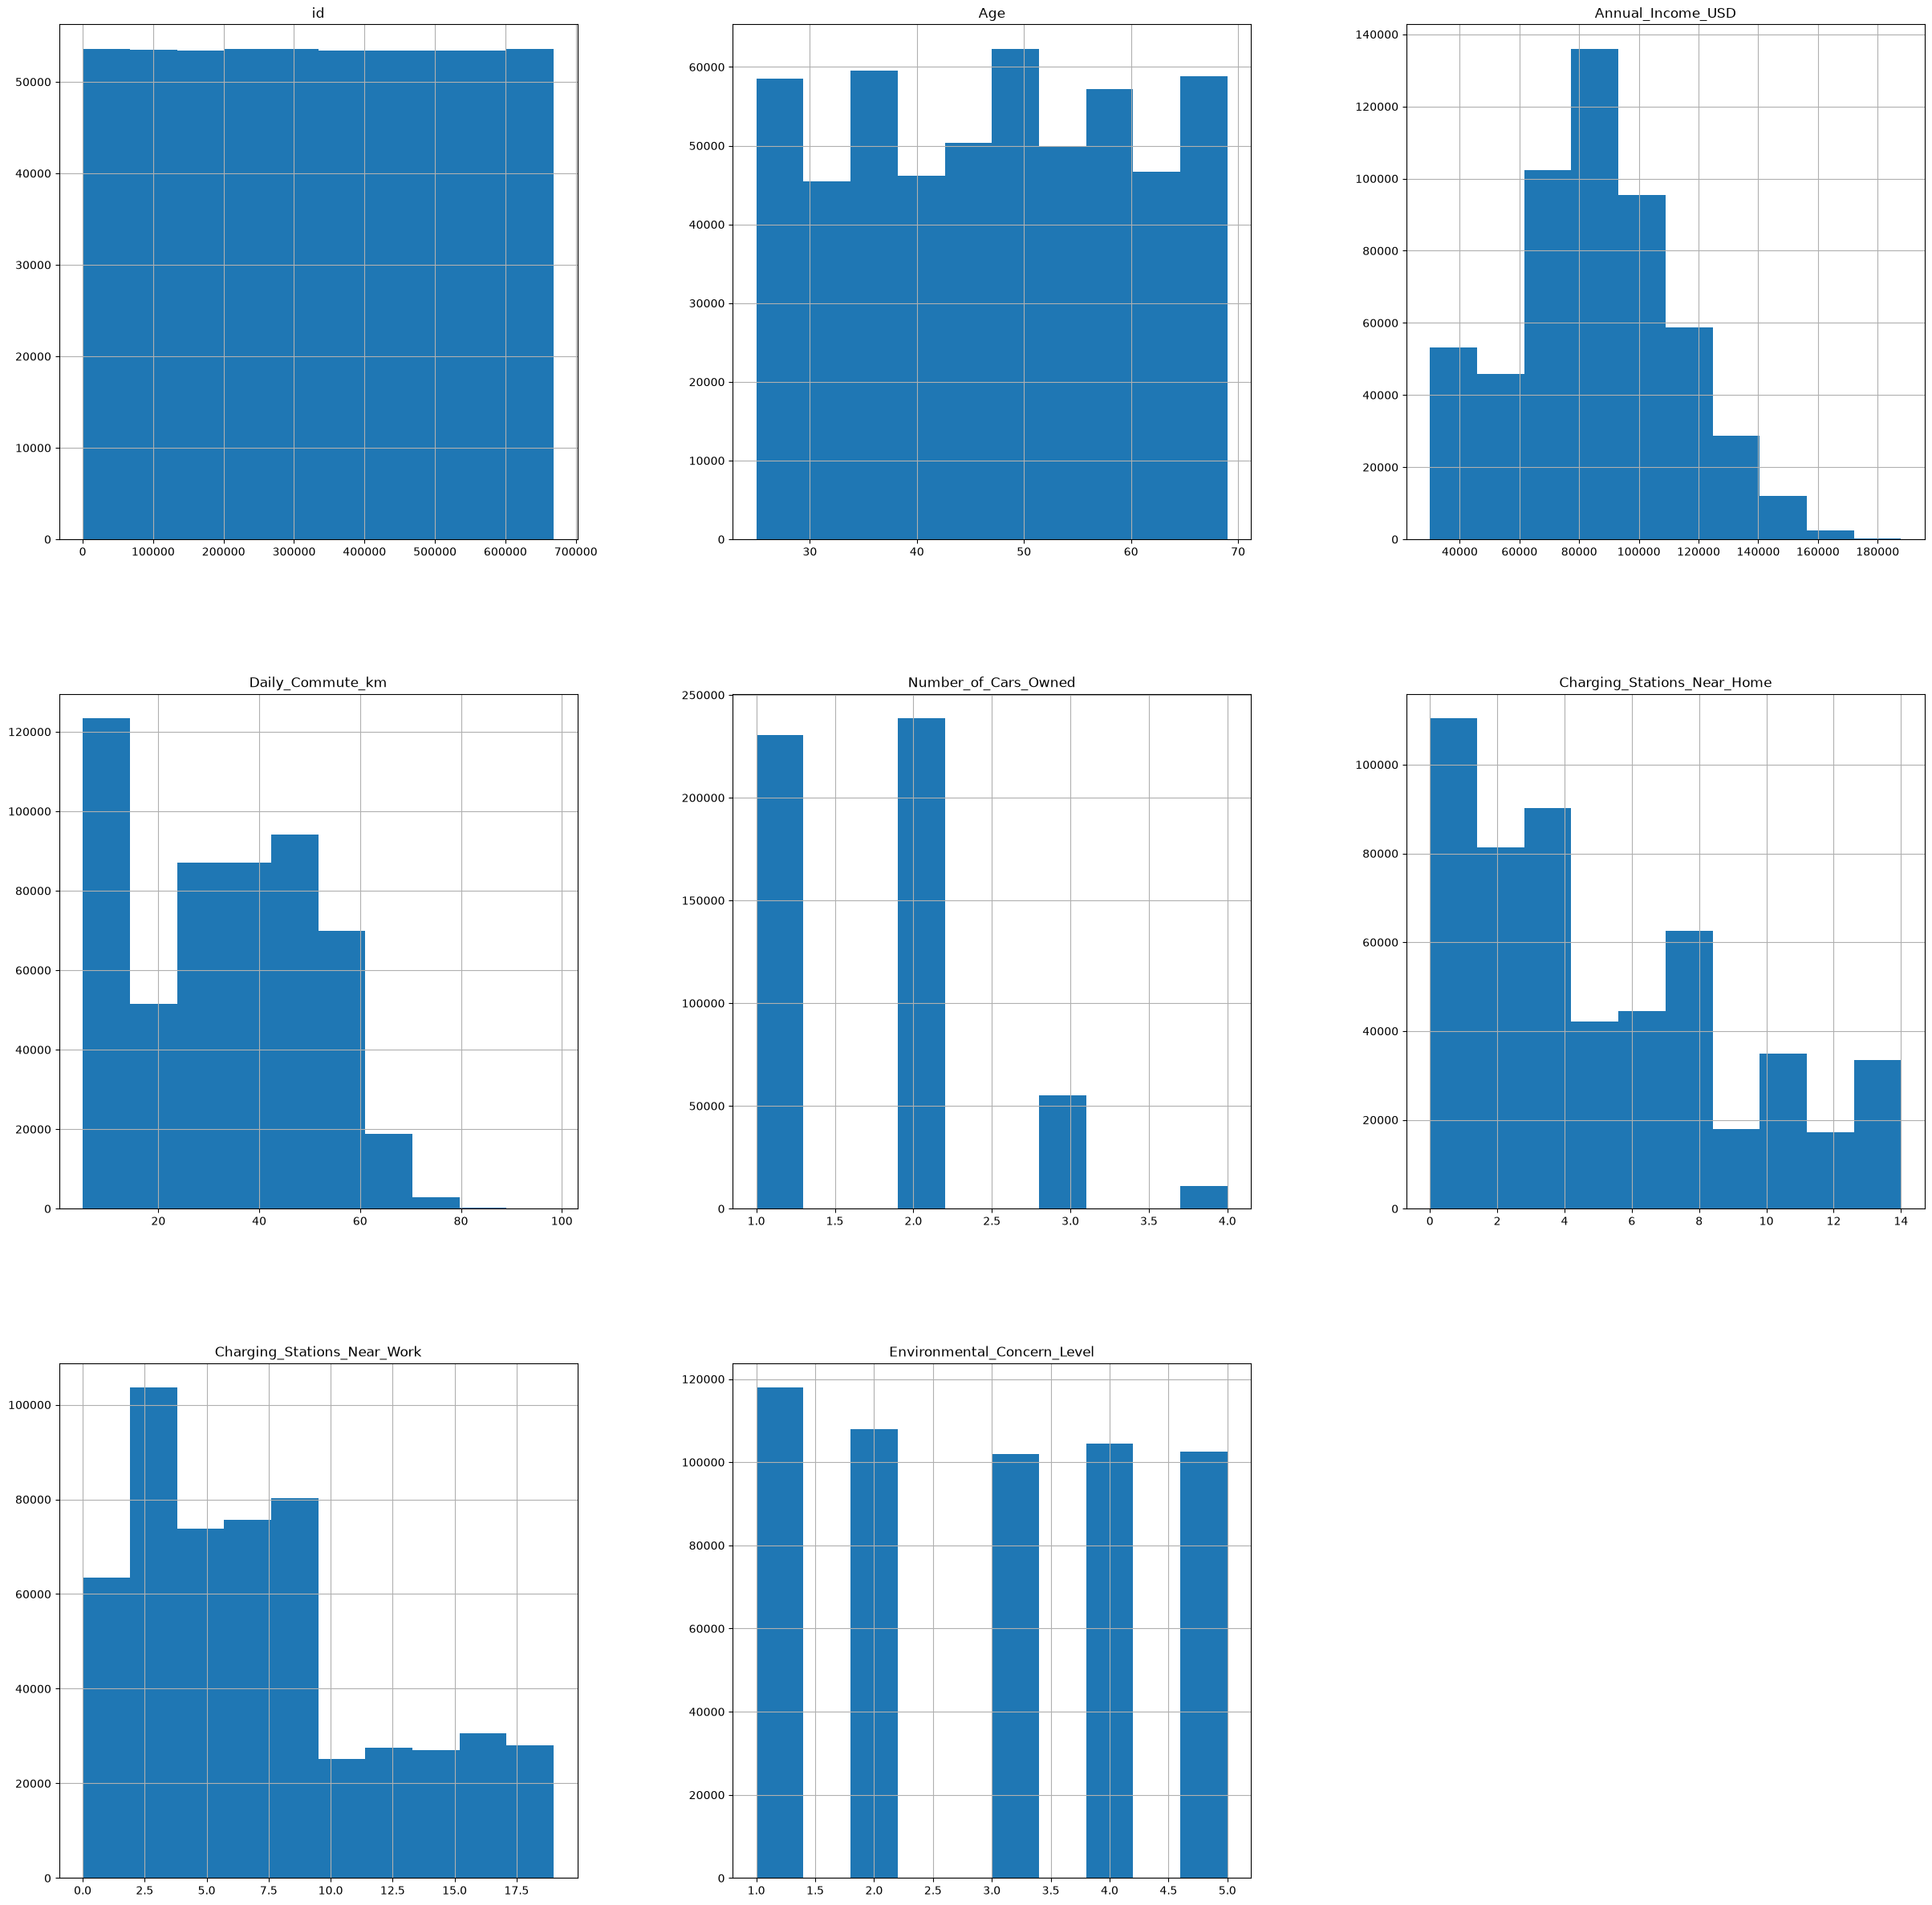

In [14]:
x_train.hist(figsize=(30,30))

In [15]:
x1 = dropper().fit_transform(x_train)
print("dropper done")

x1 = ordinalencoder().fit_transform(x1)
print("ordinal done")

x1 = OHEEncoder().fit_transform(x1)
print("ohe done")

dropper done
ordinal done
ohe done


In [16]:
x1

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,City_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Gender_Male,Gender_Other,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck
476140,66,83363.0,42.0,1,1,0,3.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
98468,29,90422.0,5.0,1,5,4,2.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
37354,32,106837.0,5.0,1,13,17,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
645575,63,123098.0,29.4,1,2,0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
280074,25,111684.0,5.0,3,0,0,4.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644167,30,30000.0,20.0,2,0,1,4.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
259178,51,82699.0,35.2,1,2,0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
365838,57,70973.0,19.5,1,2,7,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
131932,28,74923.0,5.0,1,2,3,4.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [17]:
y1=y_train
y1

476140    1
98468     0
37354     0
645575    0
280074    0
         ..
644167    0
259178    1
365838    0
131932    0
121958    0
Name: Will_Buy_EV, Length: 534932, dtype: int64

In [18]:
lr=LogisticRegression(max_iter=5000)
lr.fit(x1,y1)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [19]:
x11 = dropper().fit_transform(x_test)
print("dropper done")

x11 = ordinalencoder().fit_transform(x11)
print("ordinal done")

x11 = OHEEncoder().fit_transform(x11)
print("ohe done")

dropper done
ordinal done
ohe done


In [20]:
y_pred_lr = lr.predict(x11)
y_prob_lr = lr.predict_proba(x11)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("F1:", f1_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))

Accuracy: 0.8935715193706864
ROC-AUC: 0.9354259403227818
F1: 0.6838867295946697
Precision: 0.7052033711982412
Recall: 0.6638209804682448


In [21]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(x1,y1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [22]:
y_pred_rf = rf.predict(x11)
y_prob_rf = rf.predict_proba(x11)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

Accuracy: 0.8946931572611099
ROC-AUC: 0.9347213265630431
F1: 0.6847536543325946
Precision: 0.7120577281191807
Recall: 0.6594662182555081


In [23]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)
xgb.fit(x1, y1)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [24]:
y_pred_xgb = xgb.predict(x11)
y_prob_xgb = xgb.predict_proba(x11)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))

Accuracy: 0.8992993501977822
ROC-AUC: 0.9418294876565819
F1: 0.6979612891650032
Precision: 0.727306721510704
Recall: 0.6708920795067477


In [25]:
pipe1 = Pipeline([
    ('drop_cols', dropper()),
    ('ordinal_encode', ordinalencoder()),
    ('one_hot_encode', OHEEncoder()),
    ('model', XGBClassifier(
    n_estimators=400,
    learning_rate=0.1,
    max_depth=4,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=5,
    reg_lambda=10,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
))
])

In [26]:
param_grid = {
    'model__n_estimators': [200, 300, 400],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__min_child_weight': [1, 3, 5],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__reg_alpha': [5, 9, 12],
    'model__reg_lambda': [1, 5, 10]
}
search = RandomizedSearchCV(
    estimator=pipe1,
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

search.fit(x_train, y_train)

print("Best Parameters:")
print(search.best_params_)

print("Best ROC-AUC:")
print(search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters:
{'model__subsample': 1.0, 'model__reg_lambda': 10, 'model__reg_alpha': 5, 'model__n_estimators': 400, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
Best ROC-AUC:
0.9417023938859241


In [27]:
pipe1.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('drop_cols', ...), ('ordinal_encode', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None


In [28]:
y_pred_final=pipe1.predict(x_test)
y_prob_final = pipe1.predict_proba(x_test)[:, 1]

In [29]:
y_pred_final

array([0, 0, 0, ..., 0, 0, 0], shape=(133733,))

In [30]:
y_prob_final

array([0.01078323, 0.4386556 , 0.00212259, ..., 0.03349099, 0.00060474,
       0.01994728], shape=(133733,), dtype=float32)

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_final))
print("F1:", f1_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))

Accuracy: 0.8993965588149522
ROC-AUC: 0.9420486237171362
F1: 0.6993385179225887
Precision: 0.7259104616098353
Recall: 0.6746432113137585


In [32]:
x_test_final=pd.read_csv('test.csv')
x_test_final

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286566,955231,63,75830.0,23.9,1,3,3,1.0,Male,Suburban,SUV,Yes,No,Low
286567,955232,27,79563.0,55.2,2,7,5,3.0,Male,Suburban,Sedan,Yes,Yes,Low
286568,955233,30,48183.0,42.6,3,7,7,4.0,Female,Suburban,Sedan,Yes,No,Low
286569,955234,32,107845.0,5.0,2,14,7,1.0,Female,Urban,SUV,No,No,Low


In [33]:
y_prob_final_test=pipe1.predict_proba(x_test_final)[:,1]

In [34]:
submission = pd.DataFrame({
    'id': range(668665, 668665 + len(y_prob_final_test)),
    'Will_Buy_EV': y_prob_final_test
})

submission.to_csv('modelresxgb.csv', index=False)

In [35]:
pipe1.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('drop_cols', ...), ('ordinal_encode', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None


In [36]:
import joblib

joblib.dump(pipe1, "ev_purchase_model.pkl")

['ev_purchase_model.pkl']

In [37]:
import os

print(os.path.exists("ev_purchase_model.pkl"))

True


In [38]:
print(os.path.getsize("ev_purchase_model.pkl") / 1024 / 1024, "MB")

0.637359619140625 MB


In [39]:
model = joblib.load("ev_purchase_model.pkl")

pred = model.predict(x_test.iloc[:5])
prob = model.predict_proba(x_test.iloc[:5])[:, 1]

print(pred)
print(prob)

[0 0 0 0 1]
[1.0783235e-02 4.3865561e-01 2.1225873e-03 8.2302839e-05 5.3014165e-01]


In [40]:
joblib.dump(pipe1, "ev_purchase_model.pkl")

['ev_purchase_model.pkl']

In [41]:
print(os.getcwd())

/Users/yuvrajbiswal/Downloads/EV-Purchase-Prediction/api
